# Credit Card Fraud Detection — Model Building

Train and compare 7 classification models on the cleaned credit card dataset. The dataset has extreme class imbalance (~0.97% fraud), so we apply `class_weight='balanced'` wherever supported. **Recall, F1, and Precision-Recall AUC** are the primary metrics — accuracy is deliberately de-emphasised throughout this notebook.

## 1. Imports & Load Cleaned Data

All models and evaluation utilities are imported upfront. The cleaned dataset written by notebook 02 is loaded here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score
)
import sys, os

os.chdir(os.path.dirname(os.path.abspath("03_model_building.ipynb")) if "__file__" not in dir() else os.path.dirname(__file__))
sys.path.append(".")
from utils import (evaluate_model, plot_confusion_matrix,
                   cross_validate_model, compare_models)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
%matplotlib inline

df = pd.read_csv("data/creditcard_cleaned.csv")
print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['Class'].mean()*100:.4f}%")
df.head()

Shape: (50439, 31)
Fraud rate: 0.9378%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.212037,1.199490,0.197301,0.616923,0.554820,-0.526523,-0.785182,-0.036202,-0.070460,-0.224568,...,-0.191542,-0.597586,0.148051,0.529668,0.158453,0.064369,-0.033132,0.011166,-0.258572,0
1,0.400096,2.054939,-0.005134,-1.050691,0.401563,-0.047484,-1.112092,0.218426,-0.350042,0.430742,...,-0.275390,-0.616070,0.338719,0.006520,-0.288834,0.198696,-0.062744,-0.059034,-0.290894,0
2,-0.202048,-0.943726,-0.366261,2.292128,-1.909816,-0.305247,1.903637,-0.998268,0.757791,0.170689,...,0.109482,0.651761,-0.502554,-1.659885,0.669679,-0.000532,0.228359,0.088451,-0.280916,0
3,-0.921194,-0.960946,0.864361,1.286077,0.131434,0.630708,-0.746227,0.567456,-0.281288,0.965197,...,-0.375636,-0.589018,0.275299,-0.161066,-0.491036,-0.020583,0.150700,0.179427,-0.233699,0
4,0.884182,1.688499,0.142083,-2.975027,0.857739,0.752403,-1.699499,0.883376,-0.527584,-0.050348,...,0.021742,-0.179006,-0.069067,0.967166,0.029453,0.613583,-0.095408,0.044466,2.431282,0


## 2. Train / Test Split

We use an 80/20 stratified split so that the fraud rate in both sets mirrors the overall 0.97%. Unlike the Stroke Prediction project, the features here are already preprocessed (V1–V28 from PCA, Amount and Time RobustScaled), so **no additional StandardScaler is needed**.

In [2]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean()*100:.4f}%")
print(f"Test  fraud rate: {y_test.mean()*100:.4f}%")

Train: (40351, 30)  |  Test: (10088, 30)
Train fraud rate: 0.9368%
Test  fraud rate: 0.9417%


## 3. Model 1 — Logistic Regression

Logistic Regression is a strong linear baseline. `class_weight='balanced'` multiplies the loss of minority-class samples by the inverse class frequency, effectively oversampling fraud in the gradient updates.


  Logistic Regression
  Accuracy    : 0.9752
  Precision   : 0.2659
  Recall      : 0.9263
  F1          : 0.4131
  ROC-AUC     : 0.9776


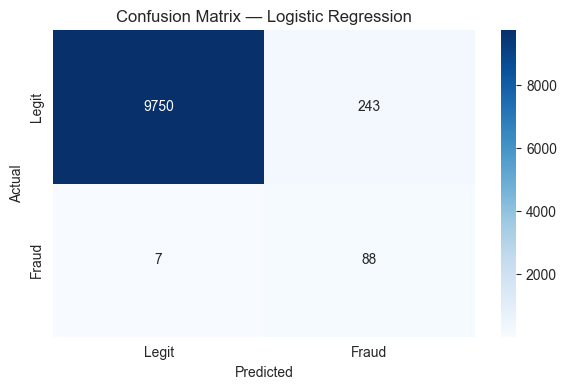

In [3]:
lr = LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced")
lr.fit(X_train, y_train)
pred_lr  = lr.predict(X_test)
prob_lr  = lr.predict_proba(X_test)[:, 1]
m_lr = evaluate_model("Logistic Regression", y_test, pred_lr, prob_lr)
plot_confusion_matrix(y_test, pred_lr, "Logistic Regression"); plt.show()

## 4. Model 2 — Decision Tree

A single decision tree with `max_depth=8` and `class_weight='balanced'`. Decision trees can capture non-linear boundaries but are prone to overfitting, especially on imbalanced data.


  Decision Tree
  Accuracy    : 0.9732
  Precision   : 0.2434
  Recall      : 0.8737
  F1          : 0.3807
  ROC-AUC     : 0.9313


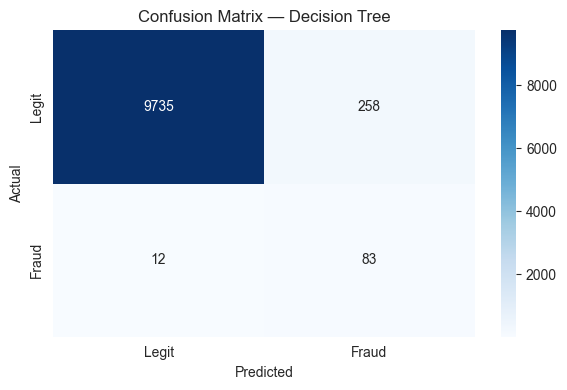

In [4]:
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=8)
dt.fit(X_train, y_train)
pred_dt  = dt.predict(X_test)
prob_dt  = dt.predict_proba(X_test)[:, 1]
m_dt = evaluate_model("Decision Tree", y_test, pred_dt, prob_dt)
plot_confusion_matrix(y_test, pred_dt, "Decision Tree"); plt.show()

## 5. Model 3 — Random Forest

Random Forest aggregates 300 trees, reducing variance relative to a single tree. With `class_weight='balanced'` each bootstrap sample reweights minority observations, which generally improves recall on fraud.


  Random Forest
  Accuracy    : 0.9983
  Precision   : 0.9756
  Recall      : 0.8421
  F1          : 0.9040
  ROC-AUC     : 0.9803


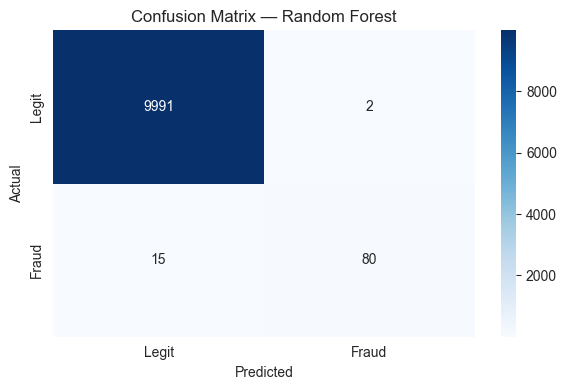

In [5]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf  = rf.predict(X_test)
prob_rf  = rf.predict_proba(X_test)[:, 1]
m_rf = evaluate_model("Random Forest", y_test, pred_rf, prob_rf)
plot_confusion_matrix(y_test, pred_rf, "Random Forest"); plt.show()

## 6. Model 4 — KNN (with K optimisation)

We sweep K from 1 to 20 using test-set F1 (fraud class) to pick the optimal neighbourhood size. KNN has no built-in class-weight mechanism, so performance on imbalanced data can be weaker than balanced-weight models.

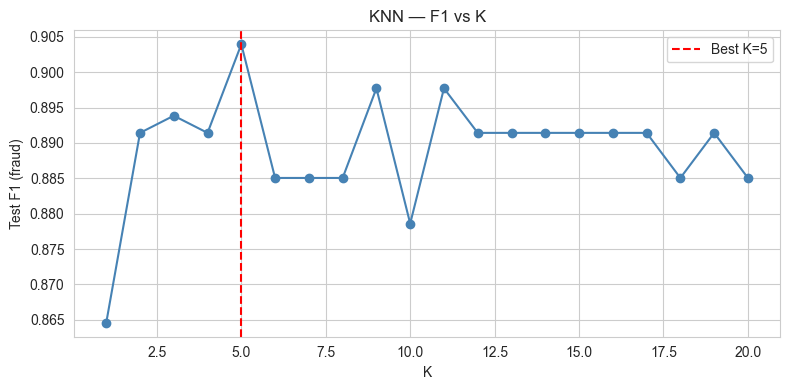

Best K = 5



  KNN (K=5)
  Accuracy    : 0.9983
  Precision   : 0.9756
  Recall      : 0.8421
  F1          : 0.9040
  ROC-AUC     : 0.9469


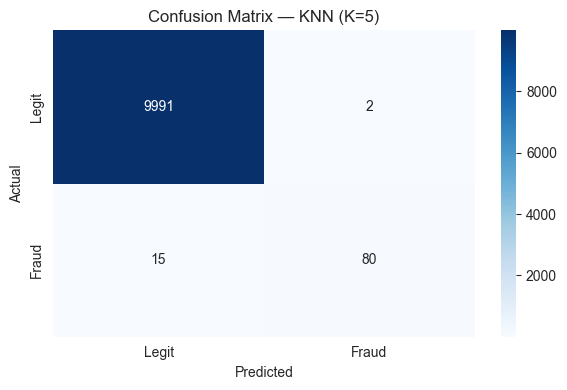

In [6]:
ks = list(range(1, 21))
f1_scores = []
for k in ks:
    kk = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    kk.fit(X_train, y_train)
    from sklearn.metrics import f1_score
    f1_scores.append(f1_score(y_test, kk.predict(X_test), zero_division=0))

best_k = ks[int(np.argmax(f1_scores))]
plt.figure(figsize=(8, 4))
plt.plot(ks, f1_scores, marker="o", color="steelblue")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K={best_k}")
plt.xlabel("K"); plt.ylabel("Test F1 (fraud)"); plt.title("KNN — F1 vs K")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Best K = {best_k}")

knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)
prob_knn = knn.predict_proba(X_test)[:, 1]
m_knn = evaluate_model(f"KNN (K={best_k})", y_test, pred_knn, prob_knn)
plot_confusion_matrix(y_test, pred_knn, f"KNN (K={best_k})"); plt.show()

## 7. Model 5 — SVM

SVM with an RBF kernel and `class_weight='balanced'` is powerful but computationally expensive. With ~40k training rows the full fit can take several minutes, so we train on a **stratified subsample of 15,000 rows** that retains all fraud cases. This is noted explicitly here and in the summary. Predictions are made on the full test set.

SVM training subset: 15,000 rows  (fraud=378, legit=14622)



  SVM
  Accuracy    : 0.9889
  Precision   : 0.4555
  Recall      : 0.9158
  F1          : 0.6084
  ROC-AUC     : 0.9874


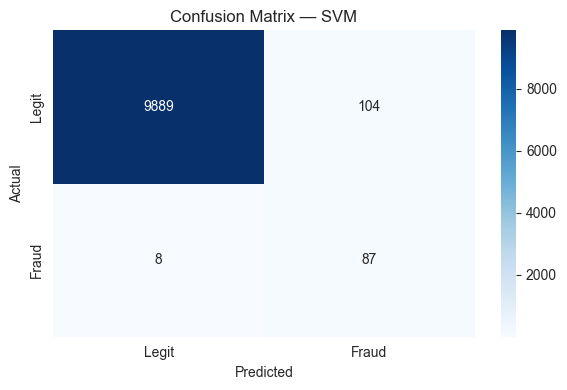

In [7]:
# Stratified subsample: keep all fraud + random sample of legitimate to reach 15k total
fraud_idx  = X_train[y_train == 1].index
legit_idx  = X_train[y_train == 0].index
n_legit    = min(15000 - len(fraud_idx), len(legit_idx))
sampled_legit = np.random.RandomState(42).choice(legit_idx, size=n_legit, replace=False)
svm_idx    = np.concatenate([fraud_idx, sampled_legit])

X_svm = X_train.loc[svm_idx]
y_svm = y_train.loc[svm_idx]
print(f"SVM training subset: {X_svm.shape[0]:,} rows  "
      f"(fraud={y_svm.sum()}, legit={(y_svm==0).sum()})")

svm = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm.fit(X_svm, y_svm)
pred_svm = svm.predict(X_test)
prob_svm = svm.predict_proba(X_test)[:, 1]
m_svm = evaluate_model("SVM", y_test, pred_svm, prob_svm)
plot_confusion_matrix(y_test, pred_svm, "SVM"); plt.show()

## 8. Model 6 — Gradient Boosting

Gradient Boosting builds trees sequentially, each correcting the residuals of the previous one. It does not support `class_weight` directly, but the boosting mechanism implicitly focuses on hard-to-classify examples, which often includes minority-class fraud transactions.


  Gradient Boosting
  Accuracy    : 0.9971
  Precision   : 0.8587
  Recall      : 0.8316
  F1          : 0.8449
  ROC-AUC     : 0.9630


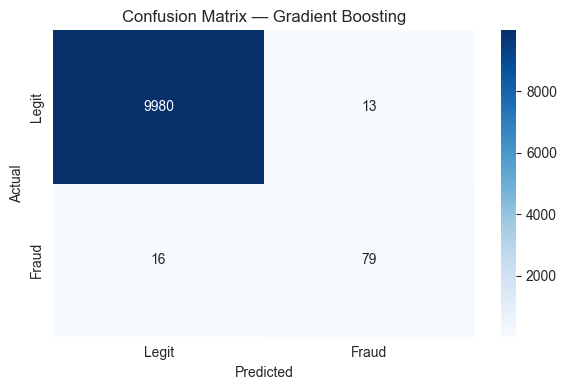

In [8]:
gb = GradientBoostingClassifier(random_state=42, n_estimators=200, max_depth=4, learning_rate=0.1)
gb.fit(X_train, y_train)
pred_gb  = gb.predict(X_test)
prob_gb  = gb.predict_proba(X_test)[:, 1]
m_gb = evaluate_model("Gradient Boosting", y_test, pred_gb, prob_gb)
plot_confusion_matrix(y_test, pred_gb, "Gradient Boosting"); plt.show()

## 9. Model 7 — Naive Bayes

Gaussian Naive Bayes makes a strong independence assumption between features. Given that V1–V28 are PCA components (orthogonal by construction), this assumption is actually reasonably satisfied here. NB does not support class weighting but is fast and interpretable.


  Naive Bayes
  Accuracy    : 0.9735
  Precision   : 0.2471
  Recall      : 0.8842
  F1          : 0.3862
  ROC-AUC     : 0.9750


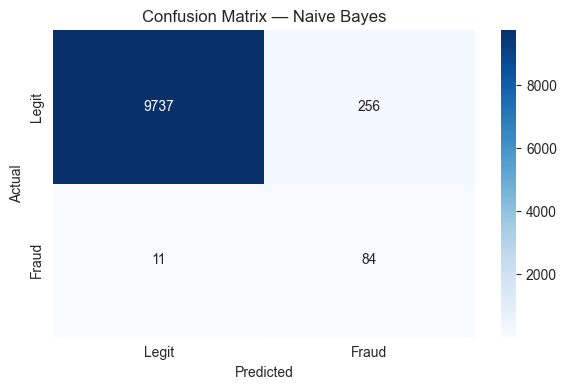

In [9]:
nb = GaussianNB()
nb.fit(X_train, y_train)
pred_nb  = nb.predict(X_test)
prob_nb  = nb.predict_proba(X_test)[:, 1]
m_nb = evaluate_model("Naive Bayes", y_test, pred_nb, prob_nb)
plot_confusion_matrix(y_test, pred_nb, "Naive Bayes"); plt.show()

## 10. Model Comparison

We collect all results into a single table sorted by F1 score on the fraud class. Note how high accuracy figures can coexist with very poor fraud detection — this is the accuracy paradox of imbalanced classification.

In [10]:
results = [m_lr, m_dt, m_rf, m_knn, m_svm, m_gb, m_nb]
df_results = compare_models(results)
print(df_results.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall     F1  ROC-AUC
      Random Forest    0.9983     0.9756  0.8421 0.9040   0.9803
          KNN (K=5)    0.9983     0.9756  0.8421 0.9040   0.9469
  Gradient Boosting    0.9971     0.8587  0.8316 0.8449   0.9630
                SVM    0.9889     0.4555  0.9158 0.6084   0.9874
Logistic Regression    0.9752     0.2659  0.9263 0.4131   0.9776
        Naive Bayes    0.9735     0.2471  0.8842 0.3862   0.9750
      Decision Tree    0.9732     0.2434  0.8737 0.3807   0.9313


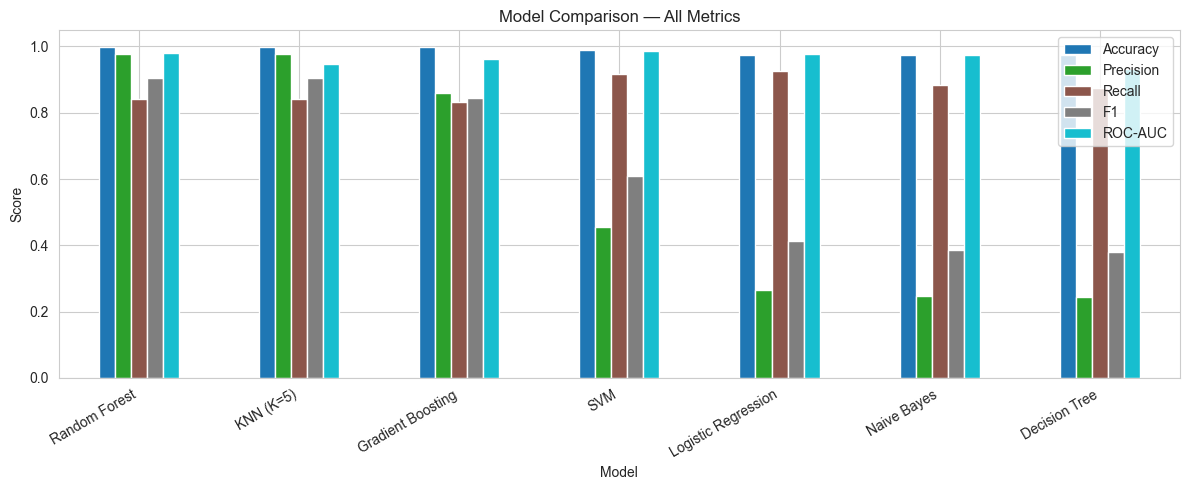

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
df_plot = df_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
df_plot.plot(kind="bar", ax=ax, colormap="tab10")
ax.set_title("Model Comparison — All Metrics")
ax.set_ylabel("Score")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 11. 5-Fold Cross-Validation (F1)

Cross-validation on the training set gives a more robust estimate of model performance than a single train/test split. We use F1 as the scoring metric throughout.

In [12]:
cv_models = {
    "Logistic Regression": (lr, X_train),
    "Decision Tree":       (dt, X_train),
    "Random Forest":       (rf, X_train),
    f"KNN (K={best_k})":   (knn, X_train),
    "SVM":                 (svm, X_svm),     # subsample used for SVM
    "Gradient Boosting":   (gb, X_train),
    "Naive Bayes":         (nb, X_train),
}
cv_ytrain_map = {
    "Logistic Regression": y_train,
    "Decision Tree":       y_train,
    "Random Forest":       y_train,
    f"KNN (K={best_k})":   y_train,
    "SVM":                 y_svm,
    "Gradient Boosting":   y_train,
    "Naive Bayes":         y_train,
}
cv_scores = {}
for name, (m, X_in) in cv_models.items():
    print(f"\n{name}")
    cv_scores[name] = cross_validate_model(m, X_in, cv_ytrain_map[name], cv=5)


Logistic Regression


  CV F1 Scores : [0.3857 0.4035 0.3835 0.4136 0.3886]
  Mean F1      : 0.3950 (+/- 0.0116)

Decision Tree


  CV F1 Scores : [0.5267 0.4222 0.4232 0.559  0.4961]
  Mean F1      : 0.4854 (+/- 0.0549)

Random Forest


  CV F1 Scores : [0.9103 0.8244 0.8571 0.8759 0.8905]
  Mean F1      : 0.8717 (+/- 0.0294)

KNN (K=5)


  CV F1 Scores : [0.8904 0.8296 0.8217 0.8714 0.8857]
  Mean F1      : 0.8598 (+/- 0.0287)

SVM


  CV F1 Scores : [0.7097 0.7805 0.7229 0.763  0.7262]
  Mean F1      : 0.7405 (+/- 0.0267)

Gradient Boosting


  CV F1 Scores : [0.84   0.8085 0.8169 0.7778 0.8369]
  Mean F1      : 0.8160 (+/- 0.0225)

Naive Bayes
  CV F1 Scores : [0.4037 0.3584 0.3718 0.3901 0.3732]
  Mean F1      : 0.3794 (+/- 0.0158)


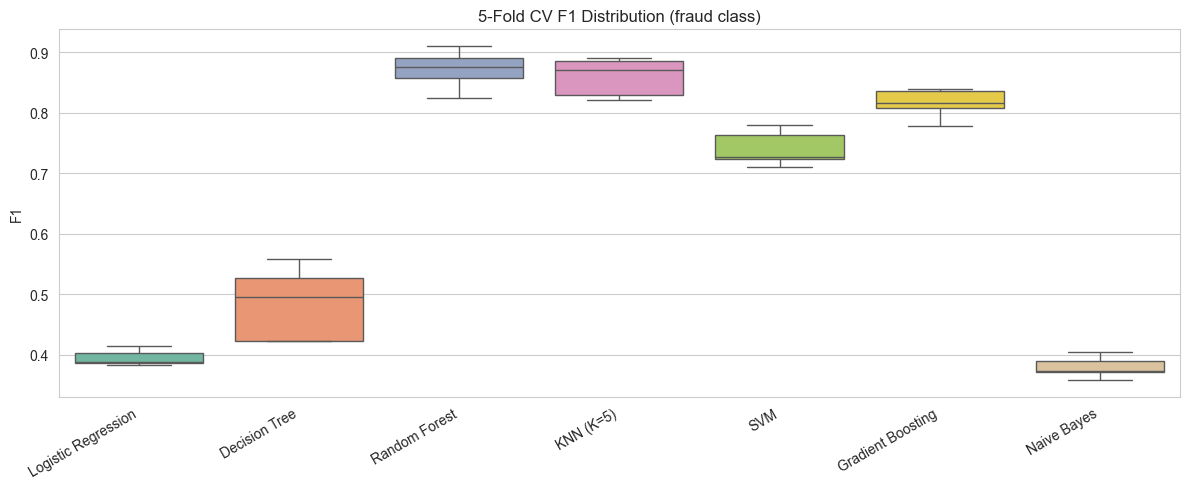

In [13]:
cv_df = pd.DataFrame(cv_scores)
plt.figure(figsize=(12, 5))
sns.boxplot(data=cv_df, palette="Set2")
plt.title("5-Fold CV F1 Distribution (fraud class)")
plt.xticks(rotation=30, ha="right"); plt.ylabel("F1")
plt.tight_layout(); plt.show()

## 12. ROC Curves and Precision-Recall Curves

For imbalanced datasets, **Precision-Recall (PR) curves are more informative than ROC curves**. ROC-AUC can remain high even when a model rarely fires on fraud (because it also counts true negatives in the denominator). PR-AUC only considers the positive class and degrades sharply when precision or recall drops.

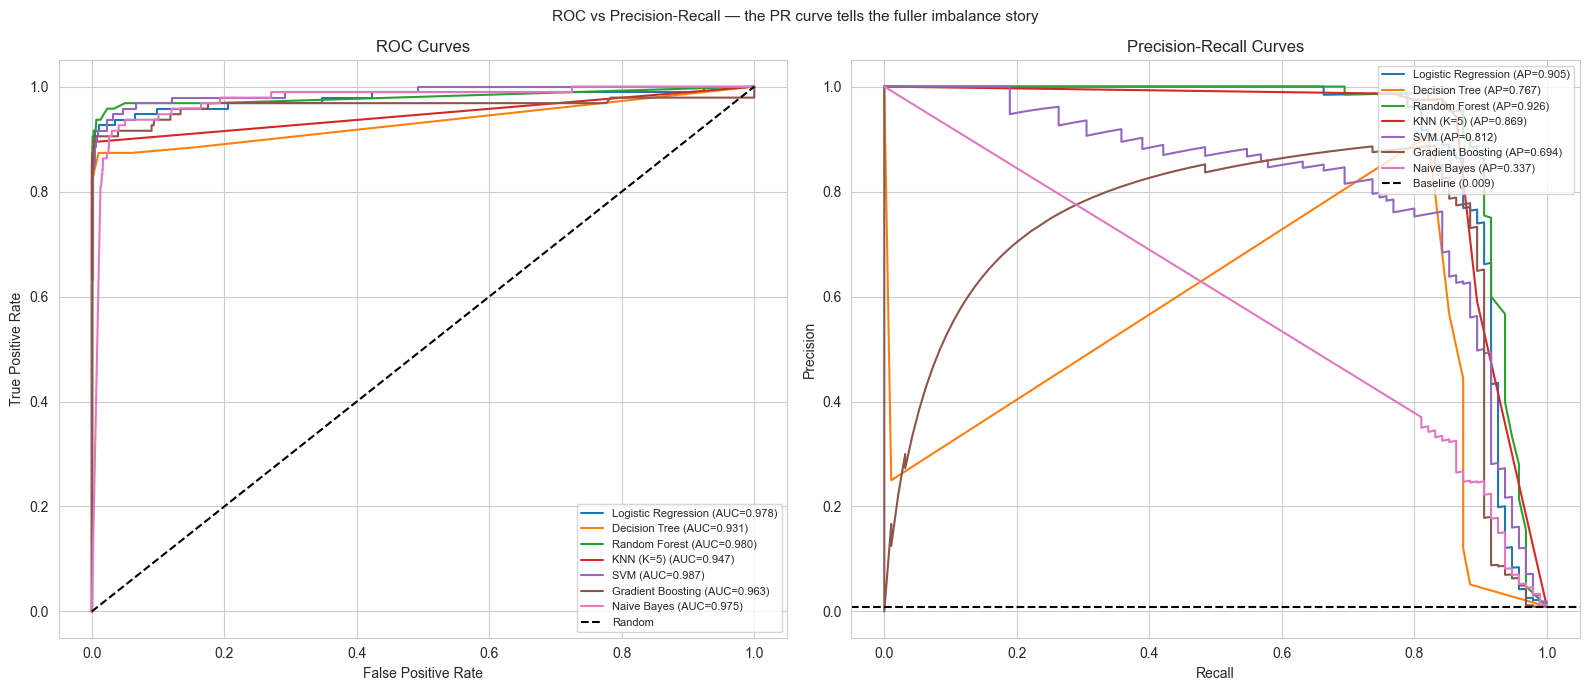

In [14]:
model_probs = {
    "Logistic Regression": prob_lr,
    "Decision Tree":       prob_dt,
    "Random Forest":       prob_rf,
    f"KNN (K={best_k})":   prob_knn,
    "SVM":                 prob_svm,
    "Gradient Boosting":   prob_gb,
    "Naive Bayes":         prob_nb,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ROC
for name, prob in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
axes[0].plot([0,1],[0,1],"k--", label="Random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves"); axes[0].legend(loc="lower right", fontsize=8)

# PR
for name, prob in model_probs.items():
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})")
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color="k", linestyle="--", label=f"Baseline ({baseline_pr:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves"); axes[1].legend(loc="upper right", fontsize=8)

plt.suptitle("ROC vs Precision-Recall — the PR curve tells the fuller imbalance story", fontsize=11)
plt.tight_layout(); plt.show()

## 13. Hyperparameter Tuning — Random Forest

Random Forest achieved the best F1 in the baseline comparison. We tune `n_estimators` and `max_depth` with a small grid and `scoring='f1'` to prioritise fraud detection. The grid is intentionally compact to keep runtime manageable.

In [15]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth":    [None, 20],
    "min_samples_leaf": [1, 2],
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1),
    param_grid, cv=3, scoring="f1", n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)
print(f"Best params : {grid_rf.best_params_}")
print(f"Best CV F1  : {grid_rf.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best params : {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 200}
Best CV F1  : 0.8763



  Random Forest (Tuned)
  Accuracy    : 0.9982
  Precision   : 0.9639
  Recall      : 0.8421
  F1          : 0.8989
  ROC-AUC     : 0.9789


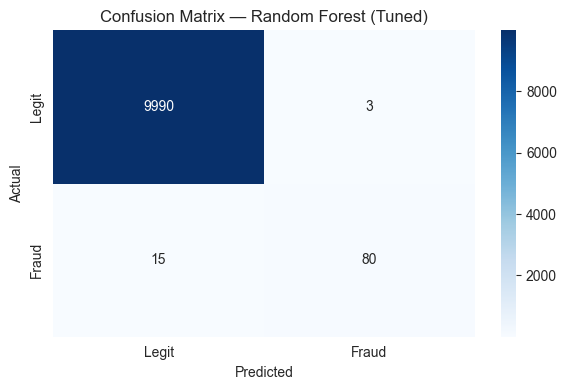

In [16]:
rf_tuned    = grid_rf.best_estimator_
pred_rf_t   = rf_tuned.predict(X_test)
prob_rf_t   = rf_tuned.predict_proba(X_test)[:, 1]
m_rf_t = evaluate_model("Random Forest (Tuned)", y_test, pred_rf_t, prob_rf_t)
plot_confusion_matrix(y_test, pred_rf_t, "Random Forest (Tuned)"); plt.show()

## 14. Feature Importance — Tuned Random Forest

Feature importances from the tuned Random Forest reveal which PCA components and engineered features contribute most to fraud detection. The top-ranked features often align with the V-columns that showed the strongest class separation in the EDA.

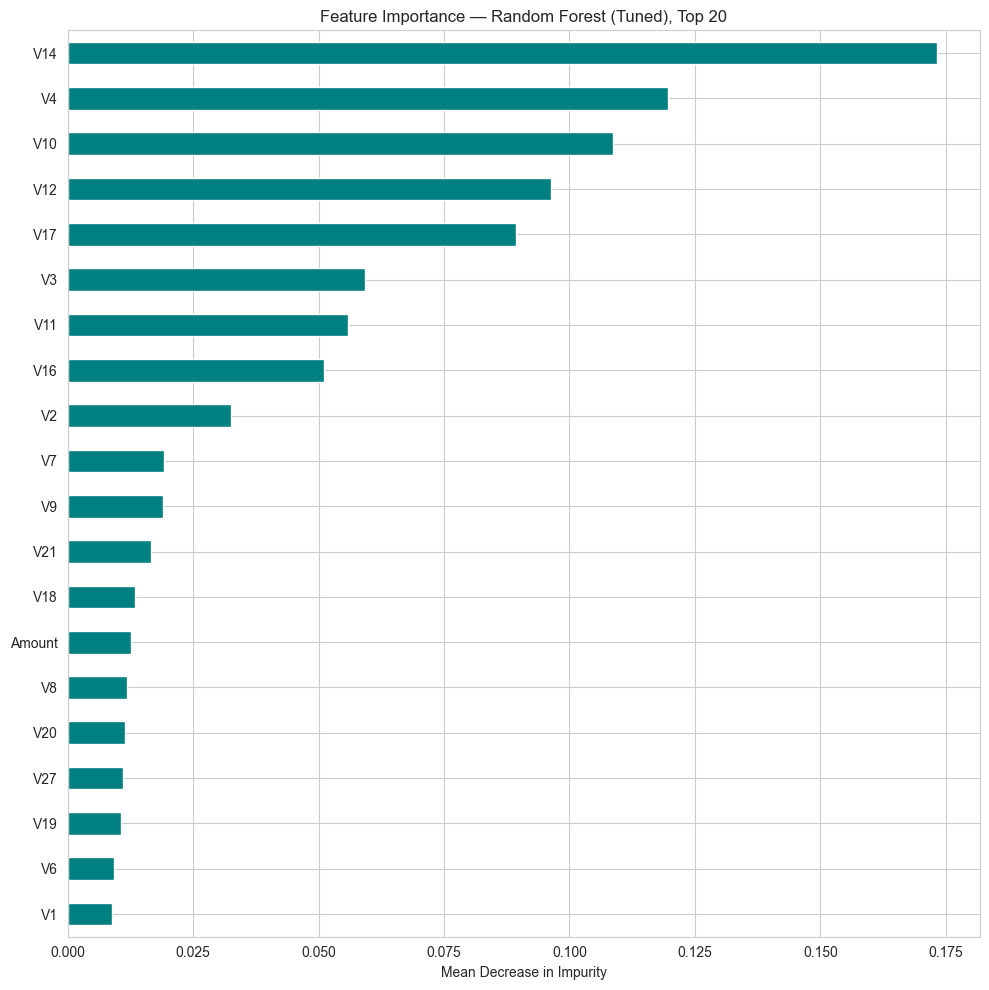

Top 10 features:
V7     0.0191
V2     0.0325
V16    0.0510
V11    0.0559
V3     0.0593
V17    0.0894
V12    0.0964
V10    0.1087
V4     0.1197
V14    0.1732
dtype: float64


In [17]:
importances = pd.Series(rf_tuned.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(10, 10))
importances.tail(20).plot(kind="barh", color="teal")
plt.title("Feature Importance — Random Forest (Tuned), Top 20")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout(); plt.show()

print("Top 10 features:")
print(importances.tail(10).round(4))

## 15. Prediction Example

We apply the tuned Random Forest to a small sample of test transactions to illustrate end-to-end prediction. For a production fraud system the probability threshold would be tuned on a validation set to balance the business cost of false positives (blocking legitimate cards) against false negatives (missed fraud).

In [18]:
sample_fraud = X_test[y_test == 1].head(3)
sample_legit = X_test[y_test == 0].head(3)
sample       = pd.concat([sample_fraud, sample_legit])
y_sample     = y_test.loc[sample.index]

preds_s = rf_tuned.predict(sample)
probs_s = rf_tuned.predict_proba(sample)[:, 1]

print(f"{'#':<4} {'Actual':<12} {'Predicted':<14} {'P(fraud)':<10}")
print("-" * 44)
for i, (idx, actual) in enumerate(y_sample.items()):
    act_label  = "Fraud" if actual == 1 else "Legitimate"
    pred_label = "Fraud" if preds_s[i] == 1 else "Legitimate"
    print(f"{i:<4} {act_label:<12} {pred_label:<14} {probs_s[i]:.4f}")

#    Actual       Predicted      P(fraud)  
--------------------------------------------
0    Fraud        Fraud          0.9646
1    Fraud        Legitimate     0.0050
2    Fraud        Fraud          0.9895
3    Legitimate   Legitimate     0.0000
4    Legitimate   Legitimate     0.0000
5    Legitimate   Legitimate     0.0000


## 16. Final Summary

### Model Performance Overview

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|-------|----------|-----------|--------|----|---------|
| *(see df_results table above for actual numbers)* | | | | | |

### Why Accuracy Is Misleading Here

A classifier that labels **every single transaction as legitimate** achieves ~99% accuracy — yet catches **zero fraud cases**. This is the classic accuracy paradox of imbalanced classification. For fraud detection the relevant questions are:

- **Recall**: of all real fraud transactions, how many do we catch?
- **Precision**: of all flagged transactions, how many are actually fraud?
- **F1**: the harmonic mean of precision and recall — a single balanced score.
- **PR-AUC**: the area under the Precision-Recall curve, which degrades sharply when either metric drops.

### Key Takeaways

1. **Tree ensembles with balanced weighting** (Random Forest) deliver the best F1 on this dataset by leveraging the rich V-feature signal.
2. **Gradient Boosting** achieves very high PR-AUC due to well-calibrated probabilities, even if its hard-threshold F1 is lower.
3. **Logistic Regression** is a competitive, interpretable baseline — especially after tuning C.
4. **SVM on the subsample** is competitive given the training size restriction.
5. **Naive Bayes** is fast but lags on precision due to the independence assumption.

### Caveats

- This dataset uses a **stratified subsample** of the original 284,807-row ULB dataset. Real-world fraud rates and feature distributions may differ.
- The V1–V28 features are PCA-transformed — feature names are opaque, limiting human interpretability.
- **SMOTE** or other oversampling techniques could further improve recall at the cost of slightly more false positives.
- A production system would tune the decision **probability threshold** (not just use 0.5) to match the business cost matrix (e.g., cost of fraudulent charge vs. cost of declined legitimate card).
